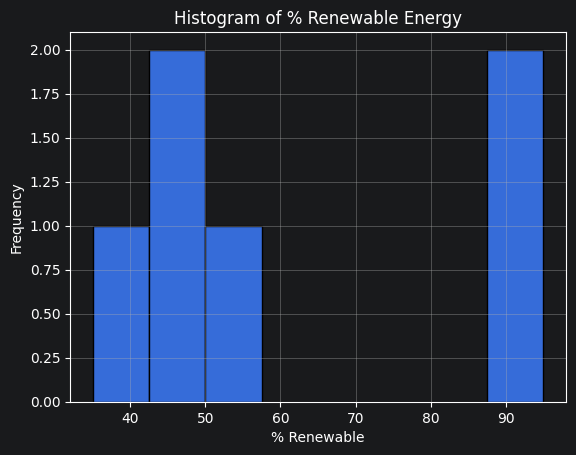

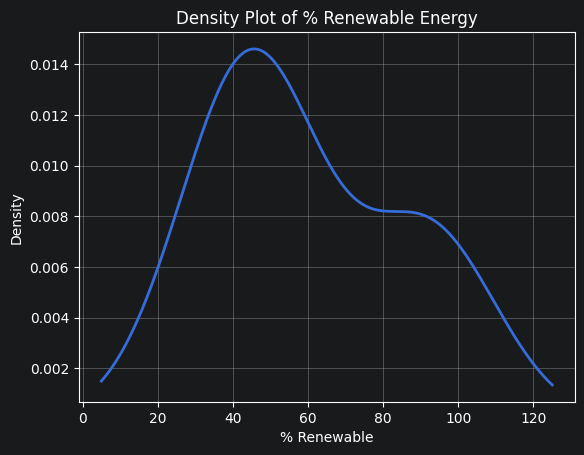

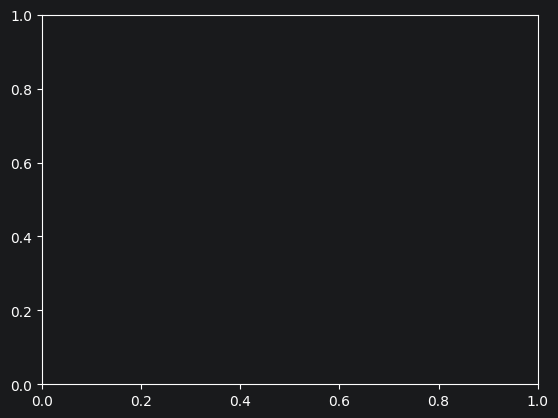

In [2]:

# Exploratory Data Analysis: Histograms and KDE

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("energy_cleaned.csv")

# Histogram
df["%Renewable"].plot(kind="hist", bins=8, edgecolor="black")
plt.title("Histogram of % Renewable Energy")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

# KDE plot (requires scipy)
df["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of % Renewable Energy")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

# KDE by Region (optional)
# A density plot needs at least two values, so skip regions with only one country.
if "Region" in df.columns:
    grouped = df.groupby("Region")["%Renewable"]
    regions_with_enough_data = grouped.filter(lambda values: values.count() > 1)

    if regions_with_enough_data.empty:
        print("Skipping KDE by Region: each region has fewer than two countries.")
    else:
        skipped_regions = grouped.count()[grouped.count() <= 1].index.tolist()
        if skipped_regions:
            print("Skipping single-country regions:", ", ".join(skipped_regions))

        regions_with_enough_data.groupby(df.loc[regions_with_enough_data.index, "Region"]).plot(
            kind="density",
            legend=True,
        )
        plt.title("Density Plot by Region")
        plt.xlabel("% Renewable")
        plt.grid(True)
        plt.show()
